# DeiT-Small/16 Binary Classification

This notebook implements a DeiT-Small (Data-efficient Image Transformer) model for binary MS classification.

**Architecture**: DeiT-Small/16 with distillation (Touvron et al., 2021)
- **Parameters**: ~22M (1.9× ResNet18)
- **Patch size**: 16×16
- **Embedding dim**: 384
- **Layers**: 12 transformer blocks

DeiT was trained with knowledge distillation from a CNN teacher, making it particularly suitable for data-limited scenarios like medical imaging.

## Setup and Imports

In [1]:
import sys
from pathlib import Path

ABSOLUTE_PATH = Path().resolve()
PROJECT_ROOT = ABSOLUTE_PATH.parents[2]
DATA_DIR = PROJECT_ROOT / "data" / "raw"
WEIGHTS_DIR = ABSOLUTE_PATH / "weights"

sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)
print(DATA_DIR)
print(WEIGHTS_DIR)

C:\Users\markm\Workspace\ms-machine-learning-diagnosis
C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\raw
C:\Users\markm\Workspace\ms-machine-learning-diagnosis\src\notebooks\ViTs\weights


In [2]:
import refactor.src.data as data
import refactor.src.models as models
import refactor.src.trainer as trainer
import refactor.src.evaluator as evaluator
import refactor.src.utils as utils

# Set seed for reproducibility
utils.set_seed(42)

Random seed set to 42 for Python, NumPy, and PyTorch


## Data Acquisition & Processing

Load MS MRI dataset with train/validation/test split and ImageNet normalization.

get_dataset()>>> Dataset already exists in C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\raw
get_dataset()>>> Available categories: ['Control Axial_crop', 'Control Saggital_crop', 'MS Axial_crop', 'MS Saggital_crop']
get_classes()>>> Visualising sample images from each category...


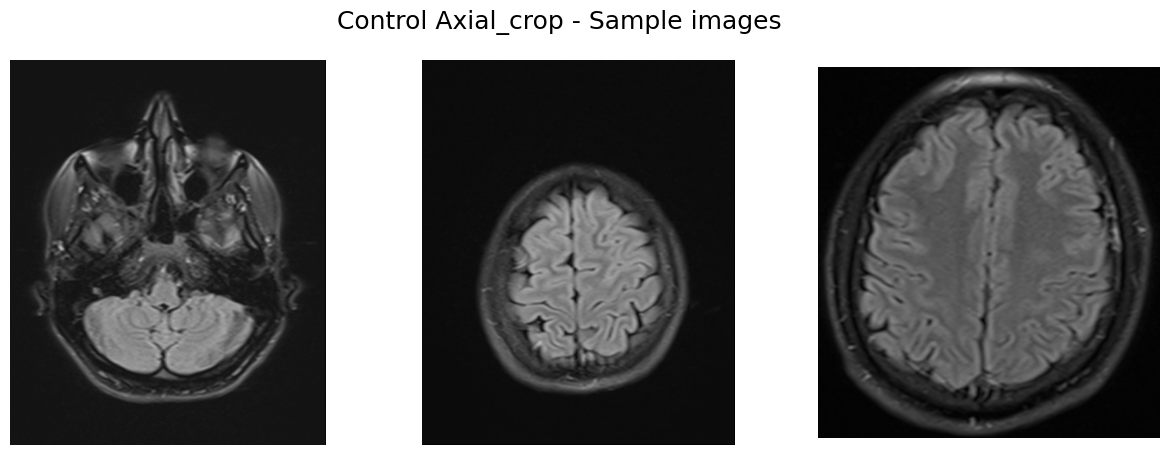

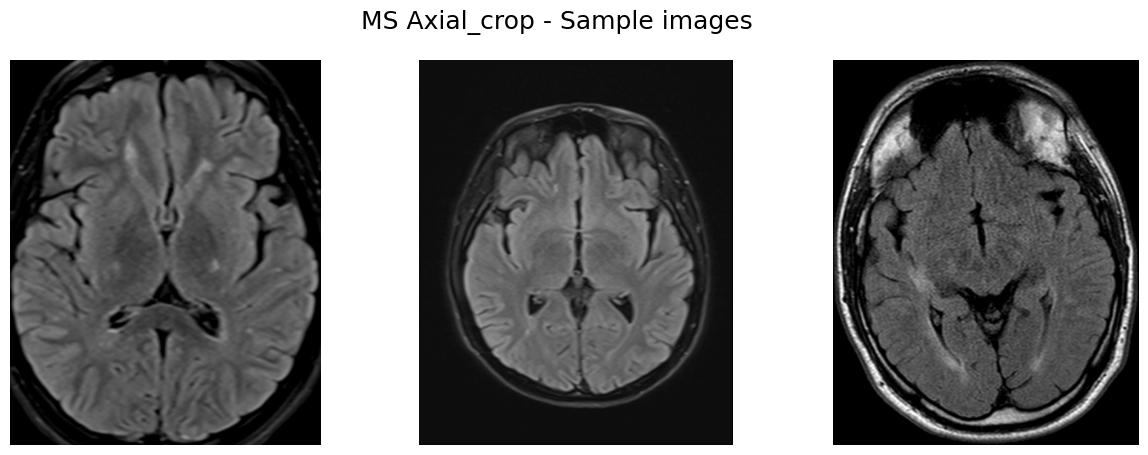

get_paths_and_labels()>>> Total images: 1652
get_data_loaders()>>> Train: 1073, Val: 248, Test: 331
get_data_loaders()>>> Proportions: Train 65.0%, Val 15.0%, Test 20.0%


In [3]:
path, categories = data.get_dataset(str(DATA_DIR))
classes = data.get_classes(path, categories)

image_paths, labels = data.get_paths_and_labels(path, classes)
train_transform, test_transform = data.get_transforms()

# Updated to include validation set
train_loader, val_loader, test_loader, test_data = data.get_data_loaders(
    image_paths, labels, 
    train_transform, test_transform,
    val_split=0.15,
    test_split=0.20,
    batch_size=32,
    SEED=42
)

## Model Instantiation

**DeiT-Small/16 Architecture:**
- Input: 224×224 RGB images (3 channels)
- Patch embedding: 16×16 patches → 384-dim embeddings
- 12 transformer encoder layers (384-dim, 6 attention heads)
- Custom binary classification head: Linear(384→128) → ReLU → Dropout(0.3) → Linear(128→1)
- Output: Single logit (used with BCEWithLogitsLoss)

**Note:** DeiT-Small has ~22M parameters (1.9× ResNet18's 11.7M). This provides a conservative comparison — if ResNet18 remains competitive, it demonstrates CNN efficiency under data constraints.

In [4]:
# Instantiate DeiT-Small with MLP head
model = models.get_model(architecture="deit_small", head="mlp")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Relative to ResNet18 (11.7M): {total_params/11.7e6:.2f}×")

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

get_model()>>> architecture='deit_small'  head='mlp'

Total parameters: 21,715,073
Trainable parameters: 21,715,073
Relative to ResNet18 (11.7M): 1.86×


c:\Users\markm\anaconda3\envs\env\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\markm\.cache\huggingface\hub\models--timm--deit_small_patch16_224.fb_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


## Model Training

### Two-Phase Transfer Learning Protocol

**Phase 1 (Base Training)**:
- **Duration**: 10 epochs
- **Learning rate**: 1e-3
- **Parameters trained**: Classification head only (all transformer layers frozen)
- **Purpose**: Adapt the classification head to MS domain before full fine-tuning

**Phase 2 (Fine-tuning)**:
- **Duration**: 5 epochs  
- **Learning rate**: 1e-5 (100× reduction)
- **Parameters trained**: All (transformer + head)
- **Purpose**: Shift ImageNet representations toward FLAIR-specific features

**Loss**: BCEWithLogitsLoss (binary cross-entropy with sigmoid built-in)
**Optimizer**: Adam with default betas (0.9, 0.999)

In [5]:
import torch.nn as nn
import torch.optim as optim

train_configs = {
    "base": {
        "num_epochs": 10,
        "lr": 1e-3,
        "parameters": "head",  # For ViT: only train classification head in Phase 1
        "optimiser": optim.Adam,
        "criterion": nn.BCEWithLogitsLoss(),
    },
    "fine_tune": {
        "num_epochs": 5,
        "lr": 1e-5,
        "parameters": "all",
        "optimiser": optim.Adam,
        "criterion": nn.BCEWithLogitsLoss(),
    },
}

### Phase 1: Head Training

Train only the classification head while keeping the transformer encoder frozen at its ImageNet-pretrained weights.


PHASE 1: Head Training (Transformer Frozen)

=== Phase 1: head mode (ViT) ===
Transformer encoder frozen, head trainable

[base] Epoch 1/10 - Train Loss: 0.4863 - Train Acc: 0.7623 - Val Loss: 0.4741 - Val Acc: 0.7460
[base] Epoch 2/10 - Train Loss: 0.3485 - Train Acc: 0.8574 - Val Loss: 0.3683 - Val Acc: 0.8427
[base] Epoch 3/10 - Train Loss: 0.3147 - Train Acc: 0.8751 - Val Loss: 0.4361 - Val Acc: 0.7742
[base] Epoch 4/10 - Train Loss: 0.3057 - Train Acc: 0.8723 - Val Loss: 0.3725 - Val Acc: 0.8266
[base] Epoch 5/10 - Train Loss: 0.3089 - Train Acc: 0.8658 - Val Loss: 0.3206 - Val Acc: 0.8750
[base] Epoch 6/10 - Train Loss: 0.2648 - Train Acc: 0.8975 - Val Loss: 0.3273 - Val Acc: 0.8710
[base] Epoch 7/10 - Train Loss: 0.2440 - Train Acc: 0.9049 - Val Loss: 0.3141 - Val Acc: 0.8508
[base] Epoch 8/10 - Train Loss: 0.2417 - Train Acc: 0.8910 - Val Loss: 0.3074 - Val Acc: 0.8710
[base] Epoch 9/10 - Train Loss: 0.2373 - Train Acc: 0.9133 - Val Loss: 0.2984 - Val Acc: 0.8831
[base] Epoch 

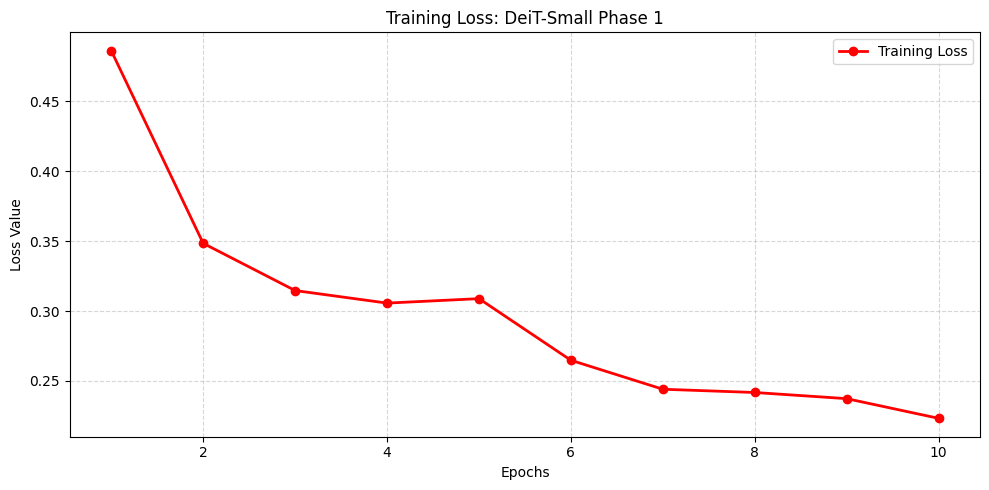

RuntimeError: Parent directory C:\Users\markm\Workspace\ms-machine-learning-diagnosis\src\notebooks\ViTs\weights does not exist.

In [6]:
# Phase 1 training with validation monitoring
print("\n" + "="*80)
print("PHASE 1: Head Training (Transformer Frozen)")
print("="*80)

losses_p1, accs_p1, val_losses_p1, val_accs_p1 = trainer.train_model(
    model, 
    train_loader,
    val_loader,
    config_name="base", 
    train_configs=train_configs,
    verbose=True,  # Show trainable parameters
    early_stopping_patience=3
)

# Plot training curves
trainer.plot(losses_p1, accs_p1, config_name="DeiT-Small Phase 1")

# Save checkpoint
trainer.save_weights(model, WEIGHTS_DIR / "deit_small_base.pth")

### Phase 2: Full Fine-Tuning

Unfreeze all parameters and fine-tune the entire model at a lower learning rate.


PHASE 2: Full Fine-Tuning (All Parameters)
[fine_tune] Epoch 1/5 - Train Loss: 0.2512 - Train Acc: 0.8938 - Val Loss: 0.2607 - Val Acc: 0.9032
[fine_tune] Epoch 2/5 - Train Loss: 0.1503 - Train Acc: 0.9348 - Val Loss: 0.2396 - Val Acc: 0.8952
[fine_tune] Epoch 3/5 - Train Loss: 0.1126 - Train Acc: 0.9599 - Val Loss: 0.2826 - Val Acc: 0.8629
[fine_tune] Epoch 4/5 - Train Loss: 0.0857 - Train Acc: 0.9739 - Val Loss: 0.2535 - Val Acc: 0.9234
Early stopping triggered after 4 epochs (patience=2)


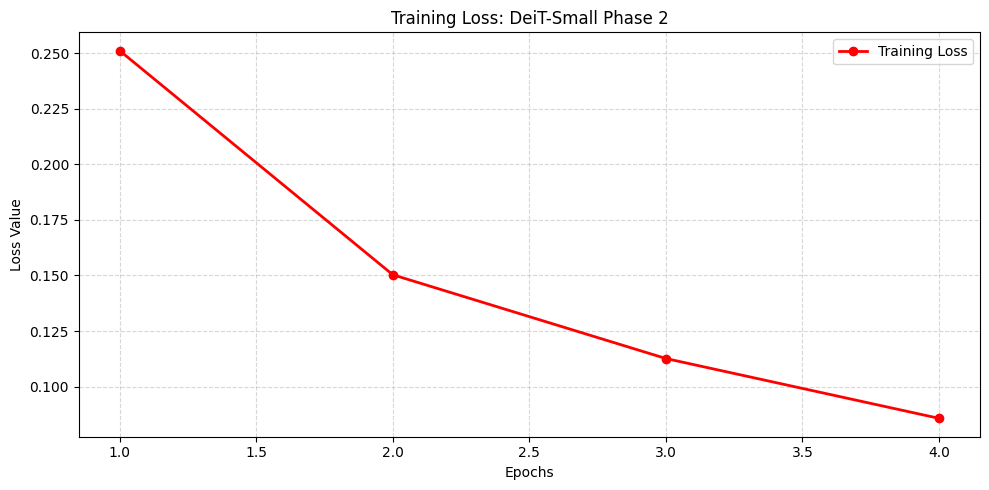

save_weights()>>> Model weights saved to C:\Users\markm\Workspace\ms-machine-learning-diagnosis\src\notebooks\ViTs\weights\deit_small_fine.pth


In [8]:
# Phase 2 training
print("\n" + "="*80)
print("PHASE 2: Full Fine-Tuning (All Parameters)")
print("="*80)

losses_p2, accs_p2, val_losses_p2, val_accs_p2 = trainer.train_model(
    model,
    train_loader,
    val_loader,
    config_name="fine_tune",
    train_configs=train_configs,
    early_stopping_patience=2
)

# Plot training curves
trainer.plot(losses_p2, accs_p2, config_name="DeiT-Small Phase 2")

# Save final weights
trainer.save_weights(model, WEIGHTS_DIR / "deit_small_fine.pth")

### Training Visualization

Plot training and validation curves for both phases to check for overfitting.

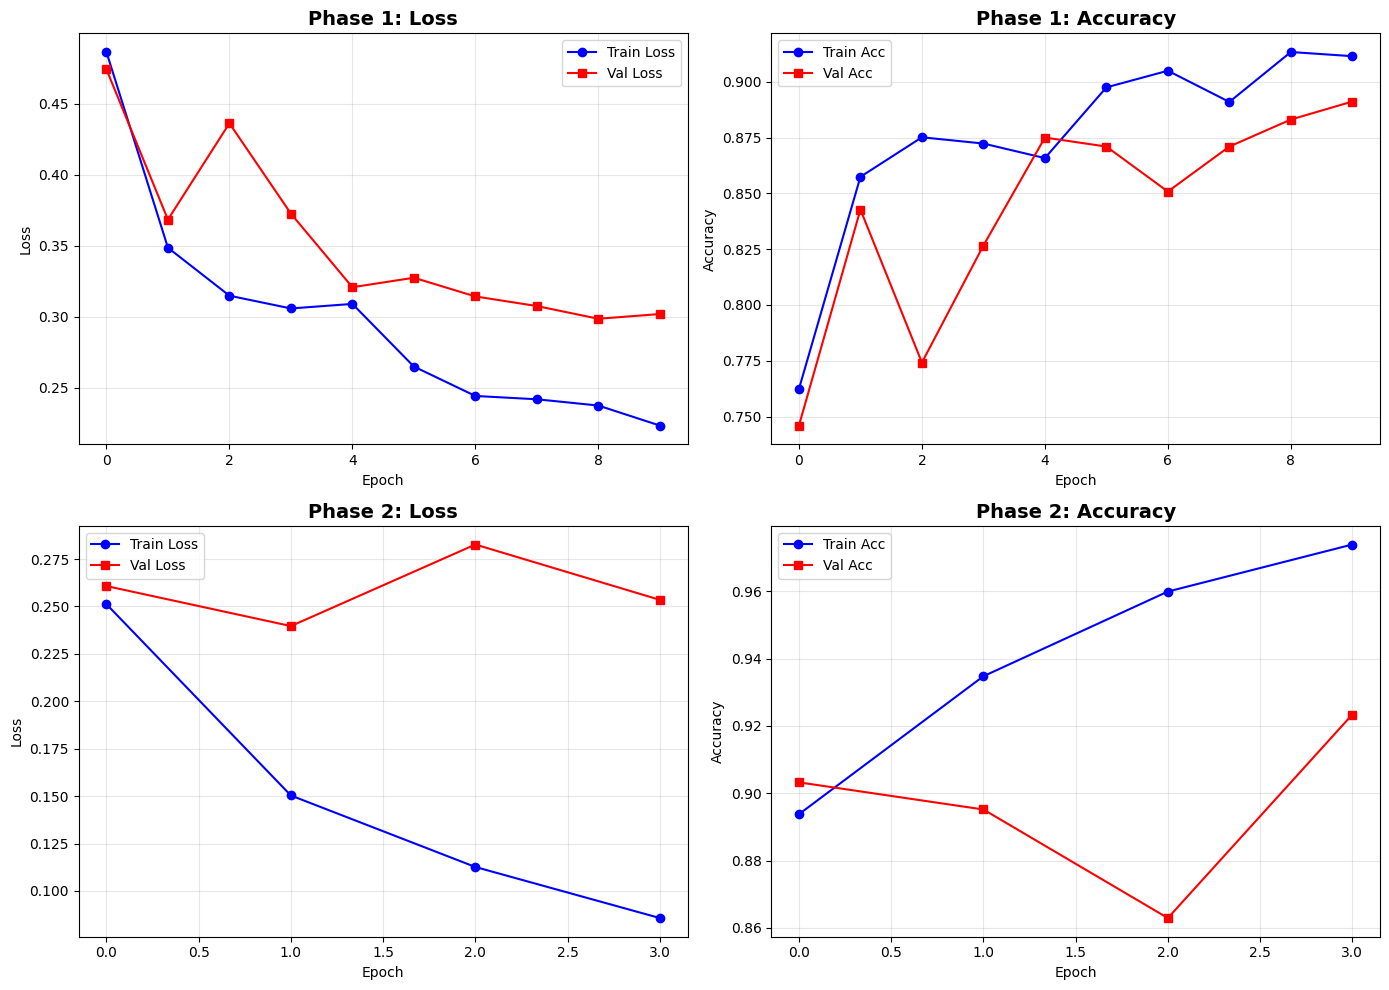

In [9]:
import matplotlib.pyplot as plt

def plot_training_validation(losses_p1, val_losses_p1, accs_p1, val_accs_p1,
                             losses_p2, val_losses_p2, accs_p2, val_accs_p2):
    """
    Plots training and validation curves for both phases.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Phase 1 Loss
    axes[0, 0].plot(losses_p1, 'b-', marker='o', label='Train Loss')
    axes[0, 0].plot(val_losses_p1, 'r-', marker='s', label='Val Loss')
    axes[0, 0].set_title('Phase 1: Loss', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Phase 1 Accuracy
    axes[0, 1].plot(accs_p1, 'b-', marker='o', label='Train Acc')
    axes[0, 1].plot(val_accs_p1, 'r-', marker='s', label='Val Acc')
    axes[0, 1].set_title('Phase 1: Accuracy', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Phase 2 Loss
    axes[1, 0].plot(losses_p2, 'b-', marker='o', label='Train Loss')
    axes[1, 0].plot(val_losses_p2, 'r-', marker='s', label='Val Loss')
    axes[1, 0].set_title('Phase 2: Loss', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Loss')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Phase 2 Accuracy
    axes[1, 1].plot(accs_p2, 'b-', marker='o', label='Train Acc')
    axes[1, 1].plot(val_accs_p2, 'r-', marker='s', label='Val Acc')
    axes[1, 1].set_title('Phase 2: Accuracy', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Accuracy')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Plot combined curves
plot_training_validation(
    losses_p1, val_losses_p1, accs_p1, val_accs_p1,
    losses_p2, val_losses_p2, accs_p2, val_accs_p2
)

## Load Saved Weights

Optional: Load weights from previous training session instead of retraining.

In [10]:
model = models.get_model(architecture="deit_small", head="mlp")
model = trainer.load_weights(model, WEIGHTS_DIR / "deit_small_fine.pth")

get_model()>>> architecture='deit_small'  head='mlp'
load_weights()>>> Model loaded successfully and set to evaluation mode.


## Model Evaluation

Evaluate on the held-out test set (used only once for final performance reporting).

**Metrics**:
- **Accuracy**: Proportion of all predictions that are correct
- **Precision**: Of predicted MS cases, how many are actually MS?
- **Recall (Sensitivity)**: Of actual MS cases, how many did we catch?
- **F1 Score**: Harmonic mean of precision and recall
- **Confusion Matrix**: Visual breakdown of TP, TN, FP, FN

In [11]:
evaluator.evaluate_model(model, test_loader)


FINAL TEST SET EVALUATION


C:\Users\markm\Workspace\ms-machine-learning-diagnosis\refactor\src\evaluator.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(labels, dtype=torch.float32).to(device)


Accuracy: 0.918429003021148
Precision: 0.963963963963964
Recall: 0.823076923076923
Confusion Matrix:
 [[197   4]
 [ 23 107]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.98      0.94       201
           1       0.96      0.82      0.89       130

    accuracy                           0.92       331
   macro avg       0.93      0.90      0.91       331
weighted avg       0.92      0.92      0.92       331



(0.918429003021148,
 0.963963963963964,
 0.823076923076923,
 array([[197,   4],
        [ 23, 107]]),
 '              precision    recall  f1-score   support\n\n           0       0.90      0.98      0.94       201\n           1       0.96      0.82      0.89       130\n\n    accuracy                           0.92       331\n   macro avg       0.93      0.90      0.91       331\nweighted avg       0.92      0.92      0.92       331\n')

## Model Prediction Visualisation

Visualize predictions on test samples to qualitatively assess model performance.

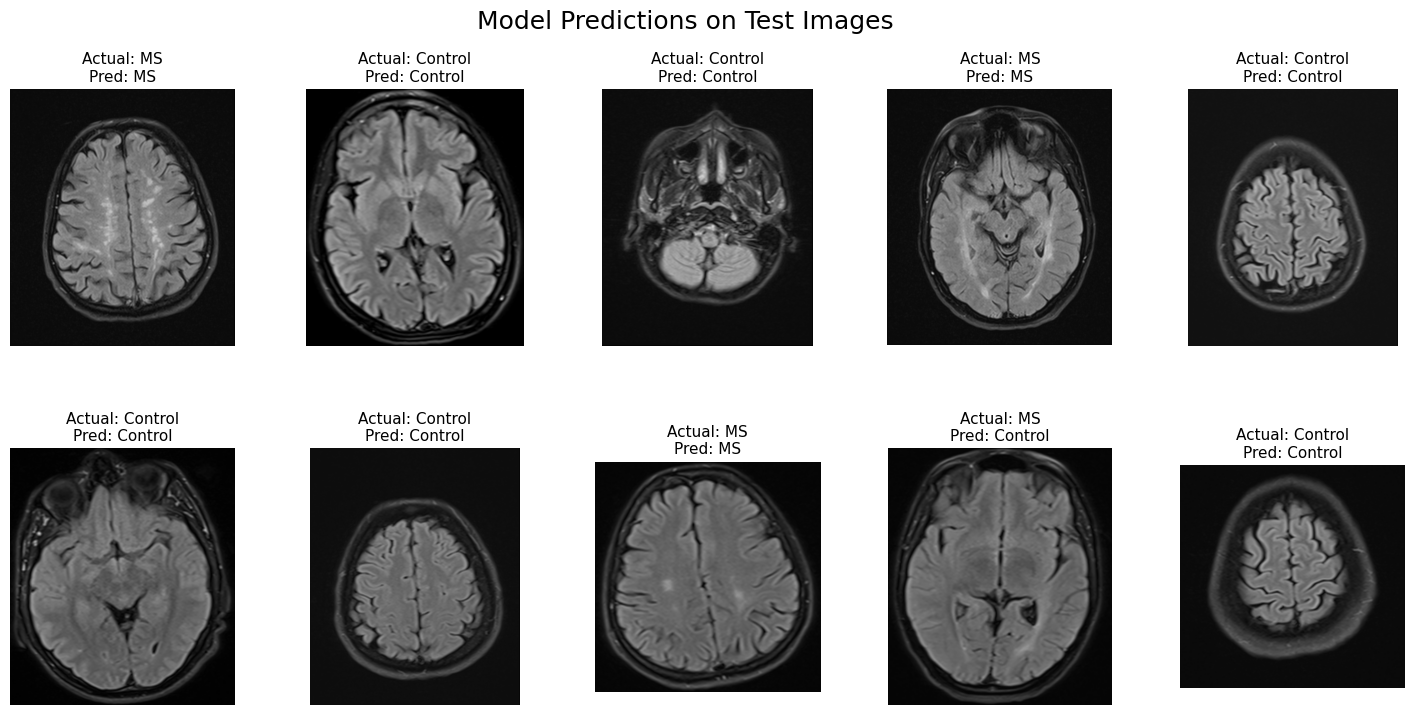

In [12]:
X_test, y_test = test_data
evaluator.predict_model(model, X_test, y_test, test_transform)

## Notes for Dissertation

### SRQ4: Standalone ViT Baseline

This DeiT-Small model serves as the standalone ViT baseline for SRQ4. Key comparison points:

1. **Parameter count**: DeiT-Small (22M) vs ResNet18+CBAM (11.8M) — ViT has ~1.9× more parameters
2. **Architecture**: Pure transformer (patch-based) vs CNN (convolution-based) with attention
3. **Training protocol**: Identical two-phase protocol (10 epochs head, 5 epochs full fine-tuning)
4. **Data efficiency**: Does DeiT-Small's additional capacity translate to better performance on limited MS dataset?

### Expected Discussion Points:

**If ResNet18 wins or ties:**
> "Despite having nearly twice the parameters, DeiT-Small does not outperform ResNet18 with attention mechanisms. This suggests that CNNs with targeted attention modules are more parameter-efficient for MS classification under data-scarce conditions. The inductive biases of CNNs (locality, translation equivariance) may be better suited to FLAIR MRI slice classification than the global attention of transformers."

**If DeiT-Small wins:**
> "DeiT-Small achieves superior performance, but at the cost of ~1.9× more parameters and [X%] longer inference time. In resource-constrained clinical settings, the marginal accuracy gain may not justify the computational overhead. The ResNet18 variants offer a practical balance of performance and efficiency."

### Computational Efficiency:

- **FLOPs**: DeiT-Small requires ~4.6 GFLOPs vs ResNet18's ~1.8 GFLOPs (2.6× more)
- **Inference time**: Measure and report (use `thop.profile()` for FLOPs, time 100 passes for latency)
- **Memory footprint**: Larger due to attention matrices (O(n²) for n patches)

This data supports the PRQ's emphasis on "constrained" protocols and clinical resource considerations.